# EDA

This notebook explores the survey data. First showing initial basic information, then checking the correlation between variables and finally displaying how each survey question was answered in the form of histograms.

In [28]:
# change directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [9]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from src.data.prepare_data import x_y_split

In [7]:
# import the data and split it into x and y (features and target)
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')
x, y = x_y_split(data)

In [8]:
# describe the data
data.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [10]:
display(Markdown('This shows what we would expect to see - the Y values fit between 0 and 1 while each X feature has values from 1 to 5.'))

This shows what we would expect to see - the Y values fit between 0 and 1 while each X feature has values from 1 to 5.

In [11]:
# show data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


In [12]:
display(Markdown('This shows that the target and each feature all have the same number of values, none of which are null. They are also all integer type'))

This shows that the target and each feature all have the same number of values, none of which are null. They are also all integer type

<Axes: >

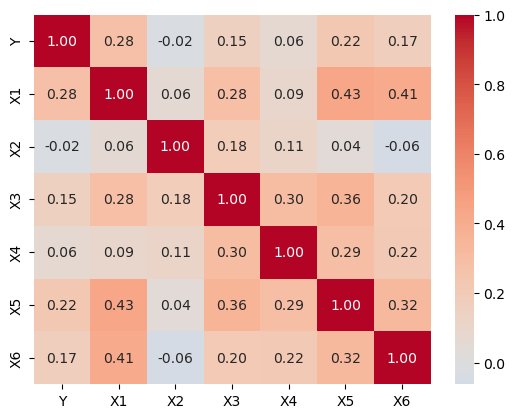

In [13]:
# create a heatmap of the correlation between each feature and the target
corr = data.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')

In [15]:
display(Markdown('This shows that there are no particularly strong correlations. The features are generally weakly correlated with the target. X1 has correlations above 0.4 with both X5 and X6.'))

This shows that there are no particularly strong correlations. The features are generally weakly correlated with the target. X1 has correlations above 0.4 with both X5 and X6.

In [21]:
# show value counts for each feature and target
for col in data.columns:
    print(data[col].value_counts())

Y
1    69
0    57
Name: count, dtype: int64
X1
5    65
4    40
3    20
1     1
Name: count, dtype: int64
X2
3    42
2    34
1    27
4    17
5     6
Name: count, dtype: int64
X3
3    55
4    33
5    17
2    14
1     7
Name: count, dtype: int64
X4
4    53
3    41
5    25
2     5
1     2
Name: count, dtype: int64
X5
4    50
5    31
3    22
2    16
1     7
Name: count, dtype: int64
X6
5    57
4    47
3    20
2     1
1     1
Name: count, dtype: int64


In [24]:
display(Markdown('This shows that there are no unexplected values - only 0 and 1 for the target and only 1, 2, 3, 4, 5 for each feature.'))

This shows that there are no unexplected values - only 0 and 1 for the target and only 1, 2, 3, 4, 5 for each feature.

In [27]:
display(Markdown('### Histograms'))

display(Markdown('Below are histograms for each feature (i.e. each survey question), showing how many customers gave each score for the question and the average score across all customers (shown by the red line).'))

### Histograms

Below are histograms for each feature (i.e. each survey question), showing how many customers gave each score for the question and the average score across all customers (shown by the red line).

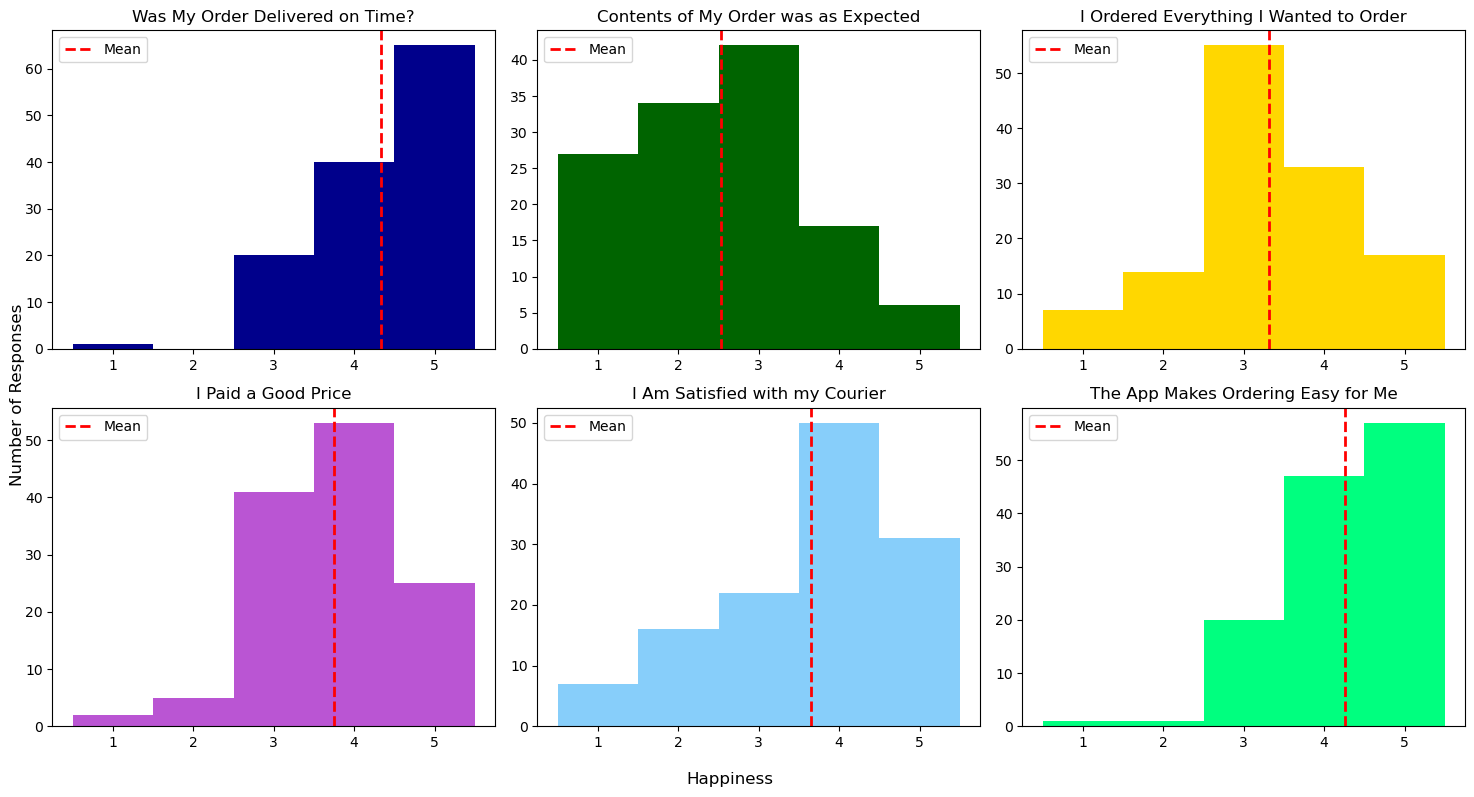

In [26]:
bins = np.arange(0.5, 6.5, 1)
xticks = range(1, 6)

plots = [
    ('X1', 'Was My Order Delivered on Time?', 'darkblue'),
    ('X2', 'Contents of My Order was as Expected', 'darkgreen'),
    ('X3', 'I Ordered Everything I Wanted to Order', 'gold'),
    ('X4', 'I Paid a Good Price', 'mediumorchid'),
    ('X5', 'I Am Satisfied with my Courier', 'lightskyblue'),
    ('X6', 'The App Makes Ordering Easy for Me', 'springgreen')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (column, title, colour) in zip(axes, plots):
    values = data[column]
    mean = np.mean(values)
    
    ax.hist(values, bins=bins, color=colour)
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label='Mean')
    ax.set_xticks(xticks)
    ax.set_title(title)
    ax.legend(loc='upper left')

fig.supxlabel('Happiness')
fig.supylabel('Number of Responses')

plt.tight_layout()
plt.show()